# **Install Libraries**

In [6]:
!pip install -q openai pandas scikit-learn matplotlib seaborn

# **Import Libraries**

In [5]:
import pandas as pd
import numpy as np

from openai import OpenAI
from getpass import getpass

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# **OpenAI API**

In [23]:
api_key = getpass("Enter your OpenAI API Key: ")

client = OpenAI(api_key=api_key)

Enter your OpenAI API Key: ··········


# **Load Dataset**

In [7]:
df = pd.read_csv("IT Support Ticket Data.csv")

# **Explore Dataset**

In [8]:
df.head()

,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  29651 non-null  int64 
 1   Body        29650 non-null  object
 2   Department  29651 non-null  object
 3   Priority    29651 non-null  object
 4   Tags        29651 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.1+ MB


In [10]:
df.shape

(29651, 5)

In [11]:
df.columns

Index(['Unnamed: 0', 'Body', 'Department', 'Priority', 'Tags'], dtype='object')

# **Check Missing Values**

In [12]:
df.isnull().sum()

,0
Unnamed: 0,0
Body,1
Department,0
Priority,0
Tags,0


# **Keep Required Columns**

In [13]:
df = df[["Body", "Department", "Tags"]]

# **Check Department Classes**

In [14]:
print(df["Department"].value_counts())

Department
Technical Support                  8617
Product Support                    5539
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64


# **Sample Data**

In [15]:
sample_df = df.sample(n=100, random_state=42).copy()

# **Sample Data**

In [16]:
sample_df = df.sample(n=100, random_state=42).copy()

# **Create Category List**

In [17]:
departments = sorted(df["Department"].unique())

print(departments)

['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']


# **Zero-Shot Classification**

In [18]:
def zero_shot(ticket):

    prompt = f"""
You are an expert IT support ticket classifier.

Classify the following support ticket into ONLY the following departments:

- Billing and Payments
- Customer Service
- General Inquiry
- Human Resources
- IT Support
- Product Support
- Returns and Exchanges
- Sales and Pre-Sales
- Service Outages and Maintenance
- Technical Support

Also predict the top 3 most relevant tags.

Return your answer ONLY in this exact format:

Department: <Department Name>
Tags: tag1, tag2, tag3

Ticket:
{ticket}
"""

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()

# **Test One Ticket**

In [19]:
print(sample_df.iloc[0]["Body"])

The encryption of health data has suddenly stopped working. It might be due to a misconfiguration in Ansible. I have restarted the servers and reviewed the SQL logs but need your help to fix this. Could you please assist?


In [24]:
print(zero_shot(sample_df.iloc[0]["Body"]))

Department: IT Support
Tags: encryption, server restart, Ansible configuration


# **Few-Shot Prompt**

In [25]:
def few_shot(ticket):

    prompt = f"""
You are an expert IT support ticket classifier.

Possible Departments:

Billing and Payments
Customer Service
General Inquiry
Human Resources
IT Support
Product Support
Returns and Exchanges
Sales and Pre-Sales
Service Outages and Maintenance
Technical Support

Examples:

Ticket:
I was charged twice for my subscription.

Department:
Billing and Payments

Tags:
Billing, Payment, Invoice

------------------------

Ticket:
The VPN connection keeps disconnecting.

Department:
Technical Support

Tags:
VPN, Network, Connectivity

------------------------

Ticket:
I want to return my order.

Department:
Returns and Exchanges

Tags:
Return, Exchange, Refund

------------------------

Now classify the following ticket.

Ticket:
{ticket}

Return ONLY

Department: ...
Tags: tag1, tag2, tag3
"""

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()

# **Run on Sample (100 Rows)**

In [26]:
sample_df["ZeroShot"] = sample_df["Body"].apply(zero_shot)

In [29]:
sample_df["FewShot"] = sample_df["Body"].apply(few_shot)

# **Extract Department**

In [30]:
sample_df["ZeroShot_Department"] = (
    sample_df["ZeroShot"]
    .str.extract(r"Department:\s*(.*)")
)

sample_df["FewShot_Department"] = (
    sample_df["FewShot"]
    .str.extract(r"Department:\s*(.*)")
)

# **Accuracy**

In [31]:
from sklearn.metrics import accuracy_score

print("Zero-Shot Accuracy")

print(
    accuracy_score(
        sample_df["Department"],
        sample_df["ZeroShot_Department"]
    )
)

Zero-Shot Accuracy
0.04


In [32]:
print("Few-Shot Accuracy")

print(
    accuracy_score(
        sample_df["Department"],
        sample_df["FewShot_Department"]
    )
)

Few-Shot Accuracy
0.0


## **Classification Report**

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        sample_df["Department"],
        sample_df["FewShot_Department"]
    )
)

                                   precision    recall  f1-score   support

             Billing and Payments       0.00      0.00      0.00       8.0
           Billing and Payments         0.00      0.00      0.00       0.0
                 Customer Service       0.00      0.00      0.00      20.0
               Customer Service         0.00      0.00      0.00       0.0
                  General Inquiry       0.00      0.00      0.00       2.0
                General Inquiry         0.00      0.00      0.00       0.0
                Human Resources         0.00      0.00      0.00       0.0
                       IT Support       0.00      0.00      0.00       8.0
                     IT Support         0.00      0.00      0.00       0.0
                  Product Support       0.00      0.00      0.00      21.0
                Product Support         0.00      0.00      0.00       0.0
            Returns and Exchanges       0.00      0.00      0.00       2.0
              Sales and 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# **Confusion Matrix**

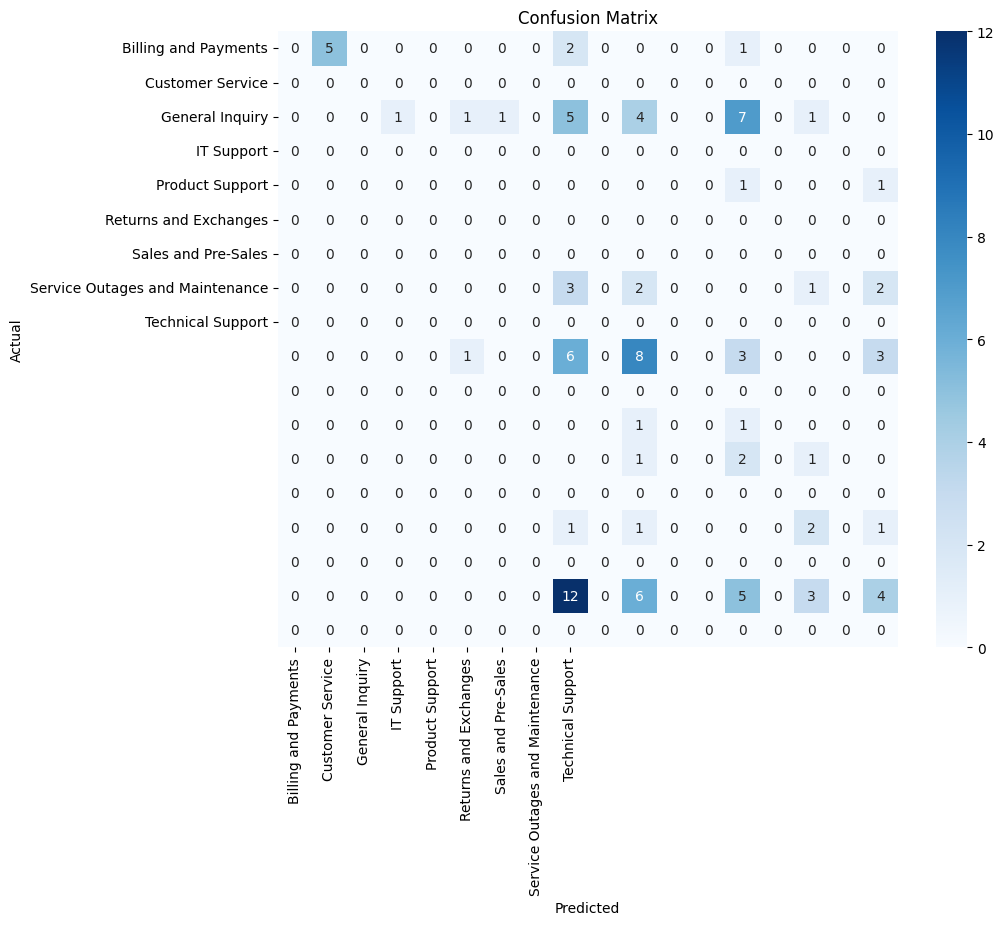

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    sample_df["Department"],
    sample_df["FewShot_Department"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(sample_df["Department"].unique()),
    yticklabels=sorted(sample_df["Department"].unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Save Results**

In [35]:
sample_df.to_csv(
    "predictions.csv",
    index=False
)

# **Download**

In [36]:
from google.colab import files

files.download("predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
print(sample_df["ZeroShot_Department"].unique())
print(sample_df["FewShot_Department"].unique())

['IT Support' 'Technical Support' 'Billing and Payments' 'Product Support'
 'Service Outages and Maintenance' 'Sales and Pre-Sales' 'General Inquiry']
['IT Support' 'Technical Support' 'Product Support' 'Billing and Payments'
 'Service Outages and Maintenance' 'Sales and Pre-Sales' 'General Inquiry'
 'Human Resources' 'Customer Service']


In [40]:
sample_df["ZeroShot_Department"] = (
    sample_df["ZeroShot_Department"]
    .astype(str)
    .str.strip()
)

sample_df["FewShot_Department"] = (
    sample_df["FewShot_Department"]
    .astype(str)
    .str.strip()
)

sample_df["Department"] = (
    sample_df["Department"]
    .astype(str)
    .str.strip()
)

In [41]:
print(sample_df["ZeroShot_Department"].unique())

print(sample_df["FewShot_Department"].unique())

['IT Support' 'Technical Support' 'Billing and Payments' 'Product Support'
 'Service Outages and Maintenance' 'Sales and Pre-Sales' 'General Inquiry']
['IT Support' 'Technical Support' 'Product Support' 'Billing and Payments'
 'Service Outages and Maintenance' 'Sales and Pre-Sales' 'General Inquiry'
 'Human Resources' 'Customer Service']


In [42]:
from sklearn.metrics import accuracy_score

zero_acc = accuracy_score(
    sample_df["Department"],
    sample_df["ZeroShot_Department"]
)

few_acc = accuracy_score(
    sample_df["Department"],
    sample_df["FewShot_Department"]
)

print("Zero-Shot Accuracy:", zero_acc)
print("Few-Shot Accuracy:", few_acc)

Zero-Shot Accuracy: 0.25
Few-Shot Accuracy: 0.25
